# Data formatting

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import cvxpy as cp
import seaborn as sns
import matplotlib

from sklearn.linear_model import LinearRegression
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import (check_X_y, check_array,check_is_fitted)
from statsmodels.tsa.arima_process import ArmaProcess
from google.colab import files
from google.colab import drive
drive.mount('/mnt/drive', force_remount=True)
from matplotlib import pyplot as plt
from cycler import cycler

Mounted at /mnt/drive


In [ ]:
!pip install geopandas shapely pyproj
import geopandas as gpd
from glob import glob
import os

In [ ]:
df_1 = (pd.read_csv("/mnt/drive/MyDrive/Colab_data/df_ct_filtered.csv")).rename(columns={"FIPS5": "FIPS"})
df_2 = (pd.read_csv("/mnt/drive/MyDrive/Colab_data/df_zip_filtered.csv"))
df_2['state'] = df_2['FIPS'].astype(str).str[0:2]
geo_city_df = pd.concat([df_1[['GEOID', 'city']], df_2[['GEOID', 'city']]]).drop_duplicates()

df_dis =pd.read_csv("/mnt/drive/MyDrive/Colab_data/Disaster.csv")

In [ ]:
# Get record from FEMA API
url = "https://www.fema.gov/api/open/v2/DisasterDeclarationsSummaries?$format=csv&$allrecords=true"

# Make it to dataframe
dec = pd.read_csv(url)

# Make FIPS code
dec['fipsStateCode'] = dec['fipsStateCode'].astype(str).str.zfill(2)
dec['fipsCountyCode'] = dec['fipsCountyCode'].astype(str).str.zfill(3)
dec['FIPS'] = dec['fipsStateCode'] + dec['fipsCountyCode']
dec['FIPS'] = dec['FIPS'].astype(str).copy()

# Get a simpler dec
dec = dec[['disasterNumber', 'state', 'designatedArea', 'fipsStateCode', 'fipsCountyCode', 'FIPS']].copy()
dec = pd.merge(dec, df_dis, left_on='disasterNumber', right_on='Num', how='left').copy()
dec = dec.dropna(subset=["month_num"]).copy()
disaster_list = dec["disasterNumber"].unique().astype(str)

In [ ]:
sc_ct =pd.read_csv("/mnt/drive/MyDrive/Colab_data/SC_ct.csv")
sc_ct['GEOID'] = sc_ct['TRACT'].astype(str).str.zfill(11).str.replace(r"\.0$", "", regex=True)
HD_ct =pd.read_csv("/mnt/drive/MyDrive/Colab_data/HD_ct.csv")
HD_ct = HD_ct.dropna(subset=['TRACT']).copy()
HD_ct['GEOID'] = HD_ct['TRACT'].astype(int).astype(str).str.zfill(11)
acs_ct =pd.read_csv("/mnt/drive/MyDrive/Colab_data/acs_ct.csv")
acs_ct['GEOID'] = acs_ct['GEOID'].astype(str).copy()

# Census Tract level

In [ ]:
!pip install geopandas shapely pyproj

In [ ]:
import geopandas as gpd
import pandas as pd
from glob import glob
import os
import zipfile

base_dir = "/mnt/drive/MyDrive/Colab_data"

zip_files = glob("/mnt/drive/MyDrive/Colab_data/*.zip")
for z in zip_files:
    with zipfile.ZipFile(z, 'r') as zip_ref:
        zip_ref.extractall("/mnt/drive/MyDrive/Colab_data")


shapefiles_2021 = glob(os.path.join(base_dir, "tl_2021_*_tract.shp"))
shapefiles_2022 = glob(os.path.join(base_dir, "tl_2022_*_tract.shp"))

shapefiles = shapefiles_2021 + shapefiles_2022

print(f"Number of shapefiles: {len(shapefiles)}")
for shp in shapefiles:
    print(shp)

gdfs = [gpd.read_file(shp) for shp in shapefiles]
tracts_all = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True), crs=gdfs[0].crs)
tracts_all = tracts_all.to_crs(epsg=3857)

Number of shapefiles: 42
/mnt/drive/MyDrive/Colab_data/tl_2021_29_tract.shp
/mnt/drive/MyDrive/Colab_data/tl_2022_47_tract.shp
/mnt/drive/MyDrive/Colab_data/tl_2022_48_tract.shp
/mnt/drive/MyDrive/Colab_data/tl_2022_45_tract.shp
/mnt/drive/MyDrive/Colab_data/tl_2022_42_tract.shp
/mnt/drive/MyDrive/Colab_data/tl_2022_18_tract.shp
/mnt/drive/MyDrive/Colab_data/tl_2022_12_tract.shp
/mnt/drive/MyDrive/Colab_data/tl_2022_01_tract.shp
/mnt/drive/MyDrive/Colab_data/tl_2022_04_tract.shp
/mnt/drive/MyDrive/Colab_data/tl_2022_05_tract.shp
/mnt/drive/MyDrive/Colab_data/tl_2022_08_tract.shp
/mnt/drive/MyDrive/Colab_data/tl_2022_06_tract.shp
/mnt/drive/MyDrive/Colab_data/tl_2022_17_tract.shp
/mnt/drive/MyDrive/Colab_data/tl_2022_21_tract.shp
/mnt/drive/MyDrive/Colab_data/tl_2022_28_tract.shp
/mnt/drive/MyDrive/Colab_data/tl_2022_27_tract.shp
/mnt/drive/MyDrive/Colab_data/tl_2022_34_tract.shp
/mnt/drive/MyDrive/Colab_data/tl_2022_36_tract.shp
/mnt/drive/MyDrive/Colab_data/tl_2022_37_tract.shp
/mnt/d

In [ ]:
tracts_all["GEOID"] = tracts_all["GEOID"].astype(str)
df_1["GEOID"] = df_1["GEOID"].astype(str)

target_tracts = tracts_all[tracts_all["GEOID"].isin(df_1["GEOID"])]

results = []

for idx, target_row in target_tracts.iterrows():
    if idx % 10 == 0:
        print(f"Processing {idx+1}/{len(target_tracts)} target tracts...")

    # ---- FIX: get a single geometry object ----
    target_geom = target_row.geometry
    target_geoid = target_row.GEOID

    # ---- spatial index: get possible matches inside buffer bounding box ----
    buffer_geom = target_geom.buffer(10_000)
    possible_idx = list(tracts_all.sindex.intersection(buffer_geom.bounds))
    possible_matches = tracts_all.iloc[possible_idx]

    # ---- final filter by actual distance ----
    nearby_tracts = possible_matches[
        possible_matches.geometry.distance(target_geom) <= 10_000
    ]

    for nearby_geoid in nearby_tracts["GEOID"]:
        results.append((target_geoid, nearby_geoid))

# Convert to DataFrame
nearby_df = pd.DataFrame(results, columns=["target_geoid", "nearby_geoid"])


Processing 11/9320 target tracts...
Processing 41/9320 target tracts...
Processing 51/9320 target tracts...
Processing 61/9320 target tracts...
Processing 71/9320 target tracts...
Processing 111/9320 target tracts...
Processing 211/9320 target tracts...
Processing 251/9320 target tracts...
Processing 291/9320 target tracts...
Processing 301/9320 target tracts...
Processing 341/9320 target tracts...
Processing 351/9320 target tracts...
Processing 371/9320 target tracts...
Processing 381/9320 target tracts...
Processing 451/9320 target tracts...
Processing 591/9320 target tracts...
Processing 601/9320 target tracts...
Processing 611/9320 target tracts...
Processing 621/9320 target tracts...
Processing 631/9320 target tracts...
Processing 651/9320 target tracts...
Processing 661/9320 target tracts...
Processing 691/9320 target tracts...
Processing 711/9320 target tracts...
Processing 721/9320 target tracts...
Processing 751/9320 target tracts...
Processing 761/9320 target tracts...
Proces

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
import matplotlib.cm as cm
from matplotlib.lines import Line2D

In [ ]:
# -----------------------------------
# Synthetic Control Class
# -----------------------------------
class SyntheticControl(BaseEstimator, RegressorMixin):
    def __init__(self):
        pass

    def fit(self, y_pre_co, y_pre_tr):
        y_pre_co, y_pre_tr = check_X_y(y_pre_co, y_pre_tr)
        w = cp.Variable(y_pre_co.shape[1])
        objective = cp.Minimize(cp.sum_squares(y_pre_co @ w - y_pre_tr))
        constraints = [cp.sum(w) == 1, w >= 0]
        prob = cp.Problem(objective, constraints)
        self.loss_ = prob.solve(verbose=False)
        self.w_ = w.value
        self.is_fitted_ = True
        return self

    def predict(self, y_co):
        check_is_fitted(self)
        y_co = check_array(y_co)
        return y_co @ self.w_

# -----------------------------------
# reshape function
# -----------------------------------
def reshape_sc_data(df, geo_col, time_col, y_col, tr_geos, tr_start):
    df_piv = df.pivot_table(values=y_col, index=time_col, columns=geo_col)
    y_co = df_piv.drop(columns=tr_geos)
    y_tr = df_piv[tr_geos]
    y_pre_co = y_co[df_piv.index < tr_start]
    y_pre_tr = y_tr[df_piv.index < tr_start]
    y_post_co = y_co[df_piv.index >= tr_start]
    y_post_tr = y_tr[df_piv.index >= tr_start]
    return y_pre_co, y_pre_tr, y_post_co, y_post_tr


=== Processing Disaster 4766 ===
145
145
0
No control GEOIDs available for disaster 4766, skipping...

=== Processing Disaster 4760 ===
0
No treatment GEOIDs available for disaster 4760, skipping...

=== Processing Disaster 4759 ===
0
No treatment GEOIDs available for disaster 4759, skipping...

=== Processing Disaster 4752 ===
0
No treatment GEOIDs available for disaster 4752, skipping...

=== Processing Disaster 4745 ===
0
No treatment GEOIDs available for disaster 4745, skipping...

=== Processing Disaster 4739 ===
0
No treatment GEOIDs available for disaster 4739, skipping...

=== Processing Disaster 4735 ===
248
420
172
--- GEOID 47157000100 completed ---
--- GEOID 47157000200 completed ---
--- GEOID 47157000300 completed ---
--- GEOID 47157000400 completed ---
--- GEOID 47157000600 completed ---
--- GEOID 47157000700 completed ---
--- GEOID 47157000800 completed ---
--- GEOID 47157000900 completed ---
--- GEOID 47157001100 completed ---
--- GEOID 47157001200 completed ---
--- GE

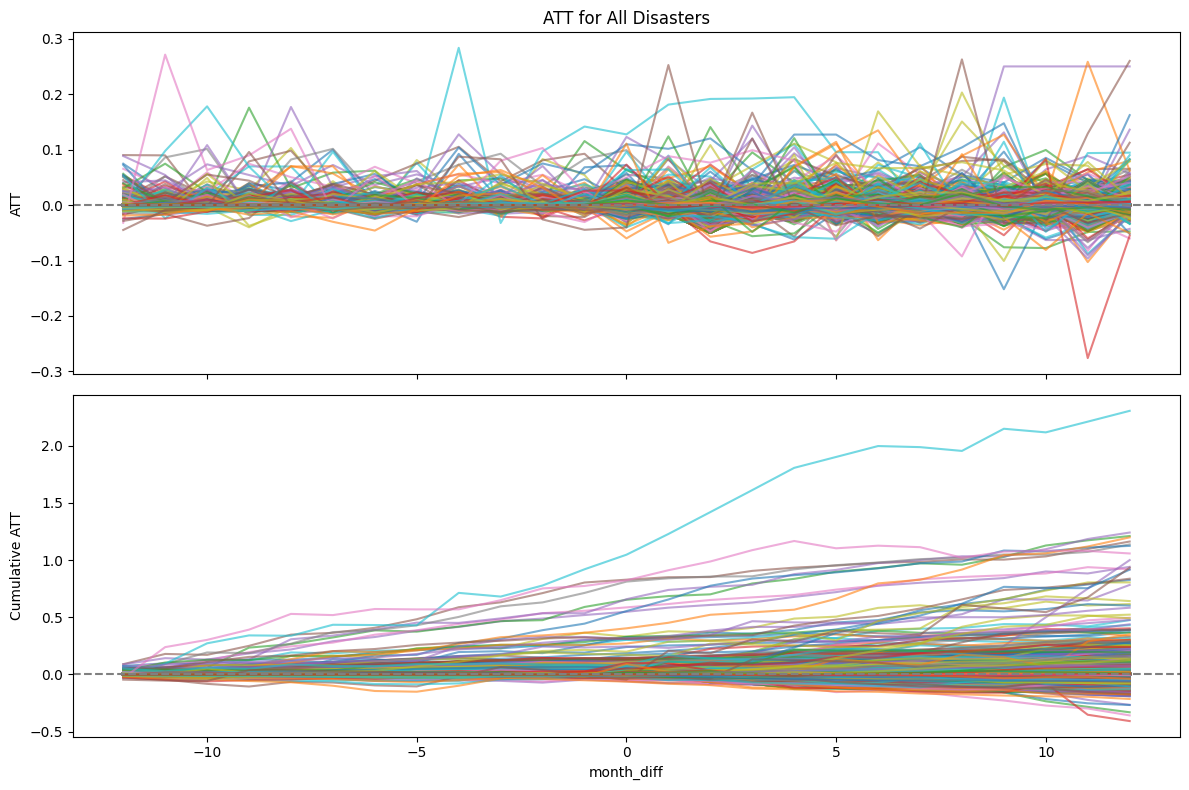

In [ ]:
disaster_list = dec["disasterNumber"].unique().astype(str)
df_1['state'] = df_1['state'].astype(str)

# Dictionary
att_all = {}
cum_att_all = {}

nearby_dict = (
    nearby_df.groupby("target_geoid")["nearby_geoid"]
    .apply(lambda x: set(x.unique()))
    .to_dict()
)

for disaster_id in disaster_list:
    print(f"\n=== Processing Disaster {disaster_id} ===")

    # --- FIPS & Treatment GEOIDs ---
    fips = dec.loc[dec["disasterNumber"].astype(str) == disaster_id, "FIPS"].unique()
    treat_geoids = df_1.loc[df_1["GEOID"].astype(str).str[:5].isin(fips), "GEOID"].unique()
    print(len(treat_geoids))
    if len(treat_geoids) == 0:
      print(f"No treatment GEOIDs available for disaster {disaster_id}, skipping...")
      continue
    impact_month = int(dec.loc[dec["disasterNumber"].astype(str) == disaster_id, "month_num"].unique()[0])

    final_exclude_geoids = set().union(*(nearby_dict.get(geo, set()) for geo in treat_geoids))

    # --- df_state & Control GEOIDs ---
    state_code = str(treat_geoids[0])[:2]
    df_state = df_1[df_1["state"] == state_code].copy()
    print(len(df_state["GEOID"].unique()))

    # --- month_diff ---
    df_state["month_diff"] = df_state["month_num"] - impact_month
    df_trim = df_state[df_state["month_diff"].between(-12, 12)].copy()

    # --- df_state & Control GEOIDs ---
    control_geoids = df_trim.loc[
        ~df_trim["GEOID"].isin(treat_geoids) & ~df_trim["GEOID"].isin(final_exclude_geoids),"GEOID"].unique()
    print(len(control_geoids))

   # Skip if there are no controls
    if len(control_geoids) == 0:
        print(f"No control GEOIDs available for disaster {disaster_id}, skipping...")
        continue

    # --- Only complete GEOIDs---
    all_months = set(range(-12, 13))
    valid_geoids = [geo for geo in list(treat_geoids) + list(control_geoids)
                    if all_months.issubset(set(df_trim.loc[df_trim["GEOID"] == geo, "month_diff"]))]

    # --- Synthetic Control ---
    for geo in treat_geoids:
        if geo not in valid_geoids:
            print(f"Treatment GEOID {geo} does not have full months, skip")
            continue

        df_tr = df_trim[df_trim["GEOID"] == geo].copy()
        df_co = df_trim[
            (df_trim["GEOID"].isin(valid_geoids)) &
            (df_trim["GEOID"].isin(control_geoids)) &
            (~df_trim["GEOID"].isin(final_exclude_geoids))
        ].copy()

        df_sc = pd.concat([df_tr, df_co])

        y_pre_co, y_pre_tr, y_post_co, y_post_tr = reshape_sc_data(
            df_sc, geo_col="GEOID", time_col="month_diff", y_col="filings_2020_p2",
            tr_geos=[geo], tr_start=0
        )

        model = SyntheticControl()
        model.fit(y_pre_co.values, y_pre_tr.mean(axis=1).values)

        y_co = pd.concat([y_pre_co, y_post_co])
        y_tr = pd.concat([y_pre_tr, y_post_tr])
        y_hat = model.predict(y_co.values)

        # --- Save ---
        key = f"{disaster_id}_{geo}"
        att_all[key] = y_tr.mean(axis=1) - y_hat
        cum_att_all[key] = att_all[key].cumsum()

        print(f"--- GEOID {geo} completed ---")

# --- Plot ---
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for key in att_all:
    axs[0].plot(att_all[key].index, att_all[key], alpha=0.6, label=key)
axs[0].axhline(0, color="gray", linestyle="--")
axs[0].set_ylabel("ATT")
axs[0].set_title("ATT for All Disasters")

for key in cum_att_all:
    axs[1].plot(cum_att_all[key].index, cum_att_all[key], alpha=0.6, label=key)
axs[1].axhline(0, color="gray", linestyle="--")
axs[1].set_xlabel("month_diff")
axs[1].set_ylabel("Cumulative ATT")

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# --- att_all -> DataFrame ---
att_list = []
for key, series in att_all.items():
    disaster_id, geo = key.split("_")
    df_tmp = pd.DataFrame({
        "disaster_id": disaster_id,
        "GEOID": geo,
        "month_diff": series.index,
        "ATT": series.values
    })
    att_list.append(df_tmp)

att_df = pd.concat(att_list, ignore_index=True)

# --- cum_att_all -> DataFrame ---
cum_att_list = []
for key, series in cum_att_all.items():
    disaster_id, geo = key.split("_")
    df_tmp = pd.DataFrame({
        "disaster_id": disaster_id,
        "GEOID": geo,
        "month_diff": series.index,
        "Cumulative_ATT": series.values
    })
    cum_att_list.append(df_tmp)

cum_att_df = pd.concat(cum_att_list, ignore_index=True)

# --- CSV ---
save_dir = "/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/"
att_df.to_csv(save_dir + "att_all_NB.csv", index=False)
cum_att_df.to_csv(save_dir + "cum_att_all_NB.csv", index=False)

print("Saved att_all_NB.csv and cum_att_all_NB.csv with GEOID and disaster_id columns.")

Saved att_all_NB.csv and cum_att_all_NB.csv with GEOID and disaster_id columns.


/tmp/ipython-input-3644848979.py:104: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


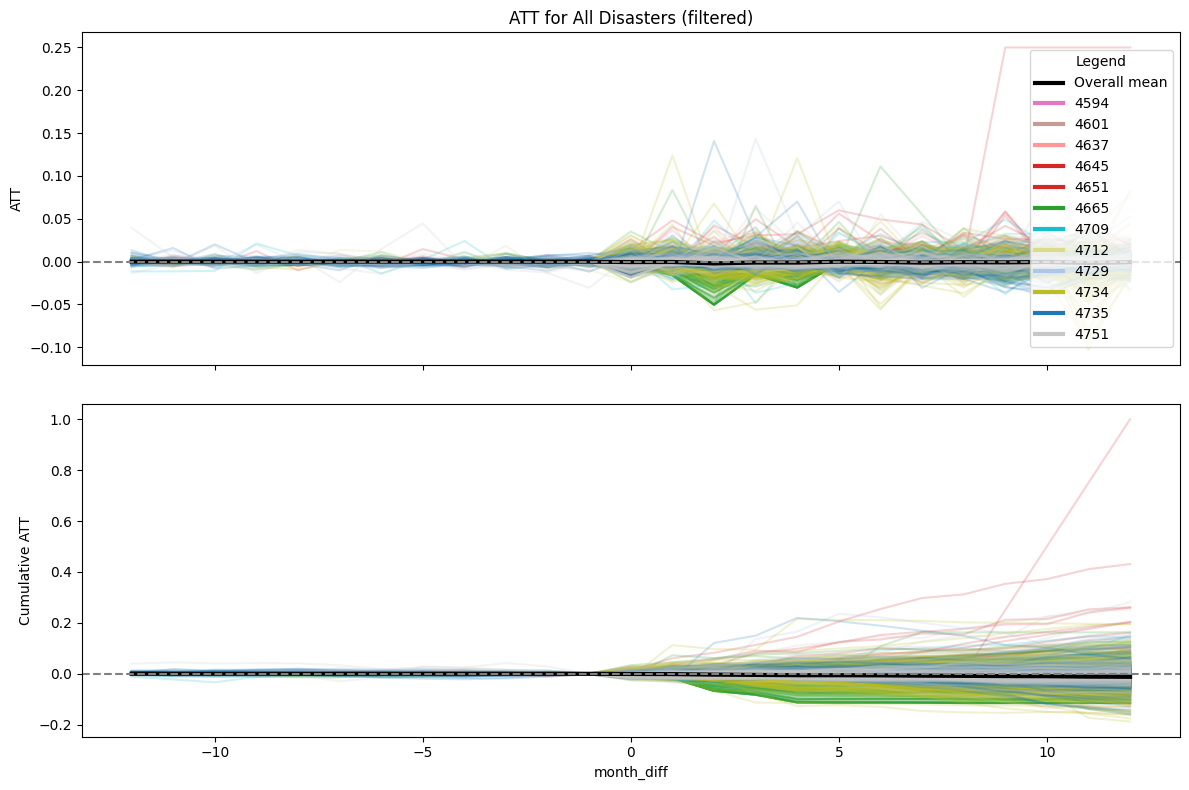

Filtered GEOIDs: ['47157000100', '47157000200', '47157000800', '47157001400', '47157001600', '47157001700', '47157001900', '47157002100', '47157002500', '47157002600', '47157002900', '47157003100', '47157003200', '47157003300', '47157003400', '47157003500', '47157003600', '47157003700', '47157003900', '47157004200', '47157004300', '47157004600', '47157006300', '47157006500', '47157006600', '47157007200', '47157007400', '47157007821', '47157008500', '47157008700', '47157008800', '47157009100', '47157009202', '47157009300', '47157009400', '47157009501', '47157009600', '47157010220', '47157010300', '47157010500', '47157010710', '47157011100', '47157011300', '47157011401', '47157020102', '47157020210', '47157020221', '47157020301', '47157020400', '47157020524', '47157020531', '47157020632', '47157020635', '47157020651', '47157020654', '47157020656', '47157020657', '47157020658', '47157020834', '47157020837', '47157020901', '47157020902', '47157021022', '47157021112', '47157021113', '471570

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

att_df = pd.read_csv("/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/att_all_NB.csv")
cum_att_df = pd.read_csv("/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/cum_att_all_NB.csv")

# --- att_all to Dict ---
att_all = {}
for (disaster_id, geo), group in att_df.groupby(["disaster_id", "GEOID"]):
    series = pd.Series(data=group["ATT"].values, index=group["month_diff"].values)
    key = f"{disaster_id}_{geo}"
    att_all[key] = series

# --- cum_att_all to Dict ---
cum_att_all = {}
for (disaster_id, geo), group in cum_att_df.groupby(["disaster_id", "GEOID"]):
    series = pd.Series(data=group["Cumulative_ATT"].values, index=group["month_diff"].values)
    key = f"{disaster_id}_{geo}"
    cum_att_all[key] = series


# --- Disaster list and colors ---
n_disasters = len(disaster_list)
cmap = plt.get_cmap('tab20')
colors = {disaster_list[i]: cmap(i / n_disasters) for i in range(n_disasters)}

# List to store GEOIDs that remain after filtering
filtered_geoids = []

# List to store all filtered ATT/Cumulative ATT series
all_att_series = []
all_cum_att_series = []

fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
legend_plots = {}

# --- t = -1 ---
cum_minus1 = []
for key, series in cum_att_all.items():
    if -1 in series.index:
        cum_minus1.append(series.loc[-1])

cum_minus1 = np.array(cum_minus1)

# --- IQR ---
Q1 = np.quantile(cum_minus1, 0.25)
Q3 = np.quantile(cum_minus1, 0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# --- Filtering ---
filtered_geoids = []
all_att_series = []
all_cum_att_series = []
legend_plots = {}

for key, cum_series in cum_att_all.items():
    if -1 in cum_series.index:
        value_minus1 = cum_series.loc[-1]
        if lower <= value_minus1 <= upper:
            disaster_id, geo = key.split('_')
            color = colors.get(disaster_id, 'gray')

            # Plot individual GEOID lines
            axs[0].plot(att_all[key].index, att_all[key], alpha=0.2, color=color)
            axs[1].plot(cum_series.index, cum_series, alpha=0.2, color=color)

            # Add to filtered GEOID list
            filtered_geoids.append(geo)

            # Store for overall mean
            all_att_series.append(att_all[key])
            all_cum_att_series.append(cum_series)

            # For legend
            if disaster_id not in legend_plots:
                legend_plots[disaster_id] = color

# --- Compute overall mean (all disasters together) ---
if len(all_att_series) > 0:
    mean_att = np.mean([s.values for s in all_att_series], axis=0)
    mean_cum_att = np.mean([s.values for s in all_cum_att_series], axis=0)

    axs[0].plot(all_att_series[0].index, mean_att, color='black', linewidth=3, label='Overall mean')
    axs[1].plot(all_cum_att_series[0].index, mean_cum_att, color='black', linewidth=3, label='Overall mean')

# Add horizontal lines at zero
axs[0].axhline(0, color="gray", linestyle="--")
axs[0].set_ylabel("ATT")
axs[0].set_title("ATT for All Disasters (filtered)")

axs[1].axhline(0, color="gray", linestyle="--")
axs[1].set_xlabel("month_diff")
axs[1].set_ylabel("Cumulative ATT")

# Add legend for disasters and overall mean
for disaster_id, color in legend_plots.items():
    axs[0].plot([], [], color=color, label=disaster_id, linewidth=3)
    axs[1].plot([], [], color=color, label=disaster_id, linewidth=3)

axs[0].legend(title="Legend", fontsize=10)

plt.tight_layout()
plt.show()

print("Filtered GEOIDs:", filtered_geoids)

In [ ]:
# -------------------------------------------------
# Filtered -> Dict
# -------------------------------------------------
filtered_att_all = {}
filtered_cum_att_all = {}

for key, cum_series in cum_att_all.items():
    if -1 in cum_series.index:
        v = cum_series.loc[-1]
        if lower <= v <= upper:
            filtered_att_all[key] = att_all[key]
            filtered_cum_att_all[key] = cum_series

# -------------------------------------------------
# filtered_att_df
# -------------------------------------------------
filtered_att_df = pd.DataFrame(
    {key: series.values for key, series in filtered_att_all.items()}
)

filtered_att_df.insert(
    0,
    "month_diff",
    next(iter(filtered_att_all.values())).index
)

# -------------------------------------------------
# filtered_cum_att_df
# -------------------------------------------------
filtered_cum_att_df = pd.DataFrame(
    {key: series.values for key, series in filtered_cum_att_all.items()}
)

filtered_cum_att_df.insert(
    0,
    "month_diff",
    next(iter(filtered_cum_att_all.values())).index
)

save_dir = "/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/"

filtered_att_df.to_csv(
    save_dir + "filtered_att_all_NB.csv",
    index=False
)

filtered_cum_att_df.to_csv(
    save_dir + "filtered_cum_att_all_NB.csv",
    index=False
)

print("Saved filtered_att_all_NB.csv and filtered_cum_att_all_NB.csv")

Saved filtered_att_all_NB.csv and filtered_cum_att_all_NB.csv


# Zip level

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
import matplotlib.cm as cm
from matplotlib.lines import Line2D

In [ ]:

import geopandas as gpd
import pandas as pd
from glob import glob
import os

base_dir = "/mnt/drive/MyDrive/Colab_data/tl_2020_us_zcta520"
shapefiles = glob(os.path.join(base_dir, "tl_2020_us_zcta520.shp"))
gdfs = [gpd.read_file(shp) for shp in shapefiles]
zip_all = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True), crs=gdfs[0].crs)
zip_all = zip_all.to_crs(epsg=3857)

In [ ]:
zip_all["GEOID"] = zip_all["GEOID20"].astype(str)
df_2["GEOID"] = df_2["GEOID"].astype(str)

target_tracts = zip_all[zip_all["GEOID"].isin(df_2["GEOID"])]

results = []

for idx, target_row in target_tracts.iterrows():
    if idx % 10 == 0:
        print(f"Processing {idx+1}/{len(target_tracts)} target tracts...")

    # ---- FIX: get a single geometry object ----
    target_geom = target_row.geometry
    target_geoid = target_row.GEOID

    # ---- spatial index: get possible matches inside buffer bounding box ----
    buffer_geom = target_geom.buffer(10_000)
    possible_idx = list(zip_all.sindex.intersection(buffer_geom.bounds))
    possible_matches = zip_all.iloc[possible_idx]

    # ---- final filter by actual distance ----
    nearby_tracts = possible_matches[
        possible_matches.geometry.distance(target_geom) <= 10_000
    ]

    for nearby_geoid in nearby_tracts["GEOID"]:
        results.append((target_geoid, nearby_geoid))

# Convert to DataFrame
nearby_df2 = pd.DataFrame(results, columns=["target_geoid", "nearby_geoid"])

Processing 621/580 target tracts...
Processing 641/580 target tracts...
Processing 681/580 target tracts...
Processing 821/580 target tracts...
Processing 1051/580 target tracts...
Processing 1401/580 target tracts...
Processing 1481/580 target tracts...
Processing 1591/580 target tracts...
Processing 1681/580 target tracts...
Processing 1771/580 target tracts...
Processing 1871/580 target tracts...
Processing 1901/580 target tracts...
Processing 1931/580 target tracts...
Processing 6721/580 target tracts...
Processing 7051/580 target tracts...
Processing 7261/580 target tracts...
Processing 7621/580 target tracts...
Processing 9041/580 target tracts...
Processing 9051/580 target tracts...
Processing 9341/580 target tracts...
Processing 9421/580 target tracts...
Processing 9591/580 target tracts...
Processing 9641/580 target tracts...
Processing 9711/580 target tracts...
Processing 9881/580 target tracts...
Processing 9891/580 target tracts...
Processing 10171/580 target tracts...
Proc

In [ ]:
# -----------------------------------
# Synthetic Control Class
# -----------------------------------
class SyntheticControl(BaseEstimator, RegressorMixin):
    def __init__(self):
        pass

    def fit(self, y_pre_co, y_pre_tr):
        y_pre_co, y_pre_tr = check_X_y(y_pre_co, y_pre_tr)
        w = cp.Variable(y_pre_co.shape[1])
        objective = cp.Minimize(cp.sum_squares(y_pre_co @ w - y_pre_tr))
        constraints = [cp.sum(w) == 1, w >= 0]
        prob = cp.Problem(objective, constraints)
        self.loss_ = prob.solve(verbose=False)
        self.w_ = w.value
        self.is_fitted_ = True
        return self

    def predict(self, y_co):
        check_is_fitted(self)
        y_co = check_array(y_co)
        return y_co @ self.w_

# -----------------------------------
# reshape function
# -----------------------------------
def reshape_sc_data(df, geo_col, time_col, y_col, tr_geos, tr_start):
    df_piv = df.pivot_table(values=y_col, index=time_col, columns=geo_col)
    y_co = df_piv.drop(columns=tr_geos)
    y_tr = df_piv[tr_geos]
    y_pre_co = y_co[df_piv.index < tr_start]
    y_pre_tr = y_tr[df_piv.index < tr_start]
    y_post_co = y_co[df_piv.index >= tr_start]
    y_post_tr = y_tr[df_piv.index >= tr_start]
    return y_pre_co, y_pre_tr, y_post_co, y_post_tr


=== Processing Disaster 4766 ===
0
No treatment GEOIDs available for disaster 4766, skipping...

=== Processing Disaster 4760 ===
0
No treatment GEOIDs available for disaster 4760, skipping...

=== Processing Disaster 4759 ===
0
No treatment GEOIDs available for disaster 4759, skipping...

=== Processing Disaster 4752 ===
0
No treatment GEOIDs available for disaster 4752, skipping...

=== Processing Disaster 4745 ===
0
No treatment GEOIDs available for disaster 4745, skipping...

=== Processing Disaster 4739 ===
0
No treatment GEOIDs available for disaster 4739, skipping...

=== Processing Disaster 4735 ===
0
No treatment GEOIDs available for disaster 4735, skipping...

=== Processing Disaster 4732 ===
0
No treatment GEOIDs available for disaster 4732, skipping...

=== Processing Disaster 4730 ===
0
No treatment GEOIDs available for disaster 4730, skipping...

=== Processing Disaster 4729 ===
0
No treatment GEOIDs available for disaster 4729, skipping...

=== Processing Disaster 4726 

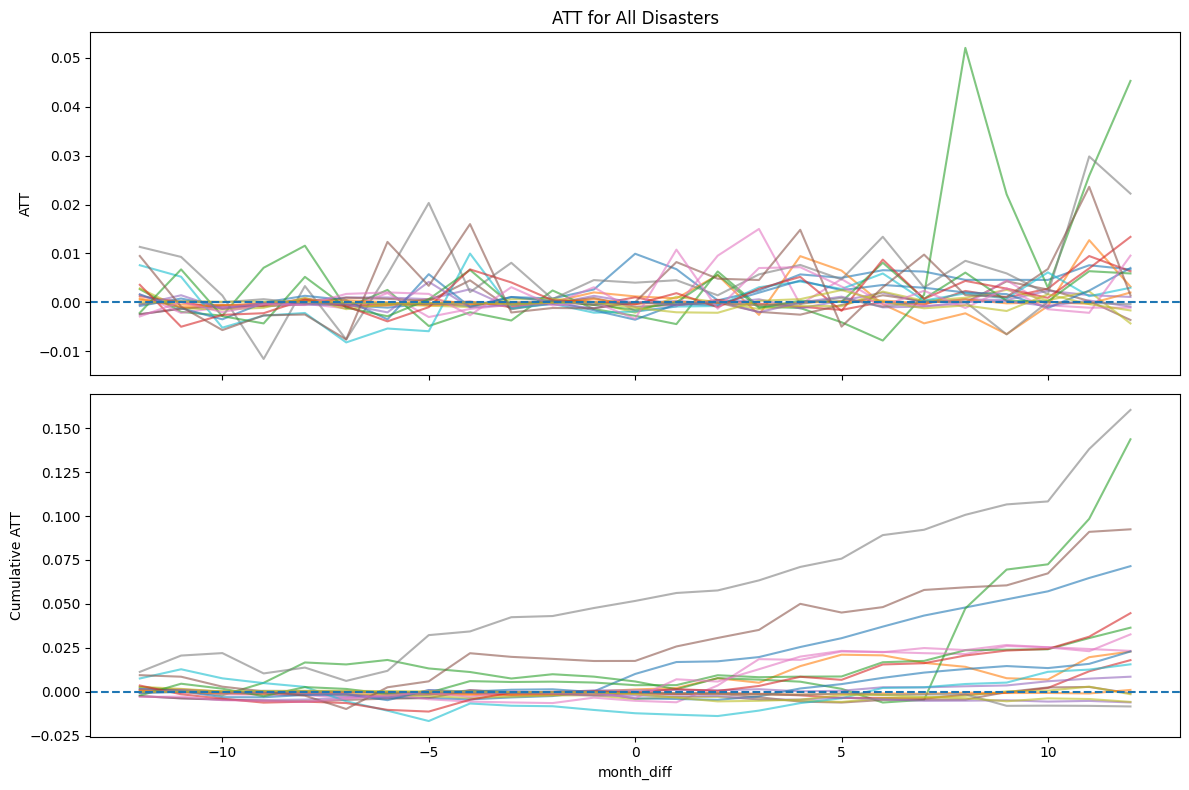

In [ ]:
disaster_list = dec["disasterNumber"].unique().astype(str)
df_2['state'] = df_2['state'].astype(str)

att_all = {}
cum_att_all = {}

# --- Nearby exclusion dictionary ---
nearby_dict = (
    nearby_df2.groupby("target_geoid")["nearby_geoid"]
    .apply(lambda x: set(x.unique()))
    .to_dict()
)

for disaster_id in disaster_list:
    print(f"\n=== Processing Disaster {disaster_id} ===")

    # --- FIPS & Treatment GEOIDs ---
    fips = dec.loc[dec["disasterNumber"].astype(str) == disaster_id, "FIPS"].unique()
    treat_geoids = df_2.loc[df_2["FIPS"].astype(str).str[:5].isin(fips), "GEOID"].unique()
    print(len(treat_geoids))
    if len(treat_geoids) == 0:
      print(f"No treatment GEOIDs available for disaster {disaster_id}, skipping...")
      continue
    impact_month = int(dec.loc[dec["disasterNumber"].astype(str) == disaster_id, "month_num"].unique()[0])
    print(impact_month)

    # --- df_state & Control GEOIDs ---
    state_code = str(fips[0])[:2]
    df_state = df_2[df_2["state"] == state_code].copy()
    print(len(df_state["GEOID"].unique()))
    control_geoids = df_state.loc[~df_state["GEOID"].isin(treat_geoids), "GEOID"].unique()
    print(len(control_geoids))
   # Skip if there are no controls
    if len(control_geoids) == 0:
        print(f"No control GEOIDs available for disaster {disaster_id}, skipping...")
        continue

    # --- month_diff ---
    df_state["month_diff"] = df_state["month_num"] - impact_month
    df_trim = df_state[df_state["month_diff"].between(-12, 12)].copy()

    # --- Only complete GEOIDs---
    all_months = set(range(-12, 13))
    valid_geoids = [geo for geo in list(treat_geoids) + list(control_geoids)
                    if all_months.issubset(set(df_trim.loc[df_trim["GEOID"] == geo, "month_diff"]))]

    # ==== Synthetic Control per treatment GEOID ====
    for geo in treat_geoids:
        if geo not in valid_geoids:
            print(f"Treatment GEOID {geo} does not have full months, skip")
            continue

        # --- Exclusion GEOIDs from nearby_dict ---
        final_exclude_geoids = nearby_dict.get(geo, set())

        # --- Build control dataframe ---
        df_co = df_trim[
            (df_trim["GEOID"].isin(valid_geoids)) &
            (df_trim["GEOID"].isin(control_geoids)) &
            (~df_trim["GEOID"].isin(final_exclude_geoids))
        ].copy()

        # --- If no controls remain, skip GEOID ---
        if df_co["GEOID"].nunique() == 0:
            print(f"No valid controls left for GEOID {geo}, skip")
            continue

        # --- Build SC dataset ---
        df_tr = df_trim[df_trim["GEOID"] == geo].copy()
        df_sc = pd.concat([df_tr, df_co])

        # --- Reshape SC data ---
        y_pre_co, y_pre_tr, y_post_co, y_post_tr = reshape_sc_data(
            df_sc, geo_col="GEOID", time_col="month_diff", y_col="filings_2020_p2",
            tr_geos=[geo], tr_start=0
        )

        # --- NaN check ---
        if y_pre_co.isna().any().any() or y_pre_tr.isna().any().any():
            print(f"NaN detected, skip GEOID {geo}")
            continue

        # --- Fit Synthetic Control ---
        model = SyntheticControl()
        model.fit(y_pre_co.values, y_pre_tr.mean(axis=1).values)

        y_co = pd.concat([y_pre_co, y_post_co])
        y_tr = pd.concat([y_pre_tr, y_post_tr])
        y_hat = model.predict(y_co.values)

        # --- Save results ---
        key = f"{disaster_id}_{geo}"
        att_all[key] = y_tr.mean(axis=1) - y_hat
        cum_att_all[key] = att_all[key].cumsum()

        print(f"--- GEOID {geo} completed ---")

# --- Final Plot ---
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for key in att_all:
    axs[0].plot(att_all[key].index, att_all[key], alpha=0.6)
axs[0].axhline(0, linestyle="--")
axs[0].set_ylabel("ATT")
axs[0].set_title("ATT for All Disasters")

for key in cum_att_all:
    axs[1].plot(cum_att_all[key].index, cum_att_all[key], alpha=0.6)
axs[1].axhline(0, linestyle="--")
axs[1].set_xlabel("month_diff")
axs[1].set_ylabel("Cumulative ATT")

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# --- att_all -> DataFrame ---
att_list = []
for key, series in att_all.items():
    disaster_id, geo = key.split("_")
    df_tmp = pd.DataFrame({
        "disaster_id": disaster_id,
        "GEOID": geo,
        "month_diff": series.index,
        "ATT": series.values
    })
    att_list.append(df_tmp)

att_df = pd.concat(att_list, ignore_index=True)

# --- cum_att_all -> DataFrame ---
cum_att_list = []
for key, series in cum_att_all.items():
    disaster_id, geo = key.split("_")
    df_tmp = pd.DataFrame({
        "disaster_id": disaster_id,
        "GEOID": geo,
        "month_diff": series.index,
        "Cumulative_ATT": series.values
    })
    cum_att_list.append(df_tmp)

cum_att_df = pd.concat(cum_att_list, ignore_index=True)

# --- CSV ---
save_dir = "/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/"
att_df.to_csv(save_dir + "att_all_zip_NB.csv", index=False)
cum_att_df.to_csv(save_dir + "cum_att_all_zip_NB.csv", index=False)

print("Saved att_all_zip_NB.csv and cum_att_all_zip_NB.csv with GEOID and disaster_id columns.")

Saved att_all_zip_NB.csv and cum_att_all_zip_NB.csv with GEOID and disaster_id columns.


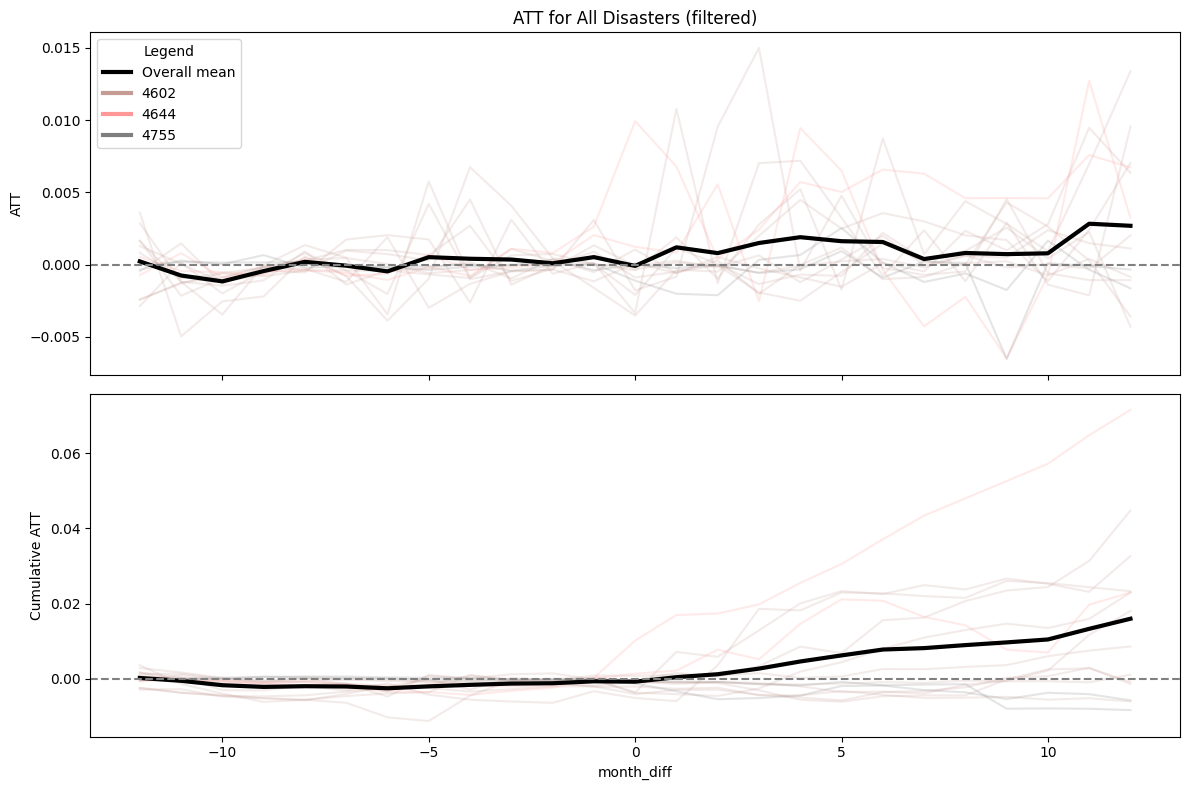

Filtered GEOIDs: ['23112', '23113', '23114', '23120', '23235', '23237', '23803', '23832', '23834', '23838', '23112', '23113', '11237', '11421']


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

att_df = pd.read_csv("/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/att_all_zip_NB.csv")
cum_att_df = pd.read_csv("/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/cum_att_all_zip_NB.csv")

# --- att_all to Dict ---
att_all = {}
for (disaster_id, geo), group in att_df.groupby(["disaster_id", "GEOID"]):
    series = pd.Series(data=group["ATT"].values, index=group["month_diff"].values)
    key = f"{disaster_id}_{geo}"
    att_all[key] = series

# --- cum_att_all to Dict ---
cum_att_all = {}
for (disaster_id, geo), group in cum_att_df.groupby(["disaster_id", "GEOID"]):
    series = pd.Series(data=group["Cumulative_ATT"].values, index=group["month_diff"].values)
    key = f"{disaster_id}_{geo}"
    cum_att_all[key] = series


# --- Disaster list and colors ---
n_disasters = len(disaster_list)
cmap = plt.get_cmap('tab20')
colors = {disaster_list[i]: cmap(i / n_disasters) for i in range(n_disasters)}

# List to store GEOIDs that remain after filtering
filtered_geoids = []

# List to store all filtered ATT/Cumulative ATT series
all_att_series = []
all_cum_att_series = []

fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
legend_plots = {}

# --- t = -1 ---
cum_minus1 = []
for key, series in cum_att_all.items():
    if -1 in series.index:
        cum_minus1.append(series.loc[-1])

cum_minus1 = np.array(cum_minus1)

# --- IQR ---
Q1 = np.quantile(cum_minus1, 0.25)
Q3 = np.quantile(cum_minus1, 0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# --- Filtering ---
filtered_geoids = []
all_att_series = []
all_cum_att_series = []
legend_plots = {}

for key, cum_series in cum_att_all.items():
    if -1 in cum_series.index:
        value_minus1 = cum_series.loc[-1]
        if lower <= value_minus1 <= upper:
            disaster_id, geo = key.split('_')
            color = colors.get(disaster_id, 'gray')

            # Plot individual GEOID lines
            axs[0].plot(att_all[key].index, att_all[key], alpha=0.2, color=color)
            axs[1].plot(cum_series.index, cum_series, alpha=0.2, color=color)

            # Add to filtered GEOID list
            filtered_geoids.append(geo)

            # Store for overall mean
            all_att_series.append(att_all[key])
            all_cum_att_series.append(cum_series)

            # For legend
            if disaster_id not in legend_plots:
                legend_plots[disaster_id] = color

# --- Compute overall mean (all disasters together) ---
if len(all_att_series) > 0:
    mean_att = np.mean([s.values for s in all_att_series], axis=0)
    mean_cum_att = np.mean([s.values for s in all_cum_att_series], axis=0)

    axs[0].plot(all_att_series[0].index, mean_att, color='black', linewidth=3, label='Overall mean')
    axs[1].plot(all_cum_att_series[0].index, mean_cum_att, color='black', linewidth=3, label='Overall mean')

# Add horizontal lines at zero
axs[0].axhline(0, color="gray", linestyle="--")
axs[0].set_ylabel("ATT")
axs[0].set_title("ATT for All Disasters (filtered)")

axs[1].axhline(0, color="gray", linestyle="--")
axs[1].set_xlabel("month_diff")
axs[1].set_ylabel("Cumulative ATT")

# Add legend for disasters and overall mean
for disaster_id, color in legend_plots.items():
    axs[0].plot([], [], color=color, label=disaster_id, linewidth=3)
    axs[1].plot([], [], color=color, label=disaster_id, linewidth=3)

axs[0].legend(title="Legend", fontsize=10)

plt.tight_layout()
plt.show()

print("Filtered GEOIDs:", filtered_geoids)

In [ ]:
# -------------------------------------------------
# Filtered -> Dict
# -------------------------------------------------
filtered_att_all = {}
filtered_cum_att_all = {}

for key, cum_series in cum_att_all.items():
    if -1 in cum_series.index:
        v = cum_series.loc[-1]
        if lower <= v <= upper:
            filtered_att_all[key] = att_all[key]
            filtered_cum_att_all[key] = cum_series

# -------------------------------------------------
# filtered_att_df
# -------------------------------------------------
filtered_att_df = pd.DataFrame(
    {key: series.values for key, series in filtered_att_all.items()}
)

filtered_att_df.insert(
    0,
    "month_diff",
    next(iter(filtered_att_all.values())).index
)

# -------------------------------------------------
# filtered_cum_att_df
# -------------------------------------------------
filtered_cum_att_df = pd.DataFrame(
    {key: series.values for key, series in filtered_cum_att_all.items()}
)

filtered_cum_att_df.insert(
    0,
    "month_diff",
    next(iter(filtered_cum_att_all.values())).index
)

save_dir = "/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/"

filtered_att_df.to_csv(
    save_dir + "filtered_att_all_zip_NB.csv",
    index=False
)

filtered_cum_att_df.to_csv(
    save_dir + "filtered_cum_att_all_zip_NB.csv",
    index=False
)

print("Saved filtered_att_all_zip_NB.csv and filtered_cum_att_all_zip_NB.csv")


Saved filtered_att_all_zip_NB.csv and filtered_cum_att_all_zip_NB.csv


# Regression

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import cvxpy as cp
import seaborn as sns
import matplotlib
import statsmodels.api as sm
import matplotlib.gridspec as gridspec

from sklearn.linear_model import LinearRegression
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import (check_X_y, check_array,check_is_fitted)
from statsmodels.tsa.arima_process import ArmaProcess
from google.colab import files
from google.colab import drive
from matplotlib import pyplot as plt
from cycler import cycler

drive.mount('/mnt/drive', force_remount=True)

Mounted at /mnt/drive


In [ ]:
sc_ct =pd.read_csv("/mnt/drive/MyDrive/Colab_data/SC_ct.csv")
sc_ct['GEOID'] = sc_ct['TRACT'].astype(str).str.zfill(11).str.replace(r"\.0$", "", regex=True)
HD_ct =pd.read_csv("/mnt/drive/MyDrive/Colab_data/HD_ct.csv")
HD_ct = HD_ct.dropna(subset=['TRACT']).copy()
HD_ct['GEOID'] = HD_ct['TRACT'].astype(int).astype(str).str.zfill(11)
acs_ct =pd.read_csv("/mnt/drive/MyDrive/Colab_data/acs_ct.csv")
acs_ct['GEOID'] = acs_ct['GEOID'].astype(str).copy()
sc_zip =pd.read_csv("/mnt/drive/MyDrive/Colab_data/SC.csv")
sc_zip = sc_zip.dropna(subset=['zip']).copy()
sc_zip['GEOID'] = sc_zip['zip'].astype(int).astype(str).str.zfill(5)
HD_zip =pd.read_csv("/mnt/drive/MyDrive/Colab_data/HD_zip.csv")
HD_zip['zipCode'] = HD_zip['zipCode'].astype(str).str.strip()
HD_zip['zipCode_clean'] = HD_zip['zipCode'].str.extract(r'(\d+)', expand=False)
HD_zip = HD_zip.dropna(subset=['zipCode_clean']).copy()
HD_zip['GEOID'] = HD_zip['zipCode_clean'].astype(int).astype(str).str.zfill(5)
acs_zip =pd.read_csv("/mnt/drive/MyDrive/Colab_data/acs_zip.csv")
acs_zip['GEOID'] = acs_zip['GEOID'].astype(int).astype(str).str.zfill(5)

sc_all = pd.concat([sc_ct, sc_zip])
HD_all = pd.concat([HD_ct, HD_zip]).iloc[:, 1:10]
acs_all = pd.concat([acs_ct, acs_zip])

df_1 = (pd.read_csv("/mnt/drive/MyDrive/Colab_data/df_ct_filtered.csv")).rename(columns={"FIPS5": "FIPS"})
df_2 = (pd.read_csv("/mnt/drive/MyDrive/Colab_data/df_zip_filtered.csv"))
df_2['state'] = df_2['FIPS'].astype(str).str[0:2]
df_dis =pd.read_csv("/mnt/drive/MyDrive/Colab_data/Disaster.csv")

geo_city_df = pd.concat([df_1[['GEOID', 'city']], df_2[['GEOID', 'city']]]).drop_duplicates()
geo_city_df['GEOID'] = geo_city_df['GEOID'].astype(str)

In [ ]:
df_fil_ct = pd.read_csv("/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/filtered_cum_att_all_NB.csv").T.iloc[1:]
df_fil_zip = pd.read_csv("/mnt/drive/MyDrive/Colab Notebooks/DisasterEviction_notebooks/ExportedData/filtered_cum_att_all_zip_NB.csv").T.iloc[1:]
df_combined = pd.concat([df_fil_ct, df_fil_zip])

df_combined = df_combined.reset_index()
df_combined = df_combined.rename(columns={'index': 'disaster_GEOID'})
df_combined[['disasterNumber', 'GEOID']] = df_combined['disaster_GEOID'].str.split('_', expand=True)

df_combined['disasterNumber'] = df_combined['disasterNumber'].astype(str)
df_combined['GEOID'] = df_combined['GEOID'].astype(str)

cum_df_12 = df_combined[[24,'GEOID']].copy()
cum_df_12 = cum_df_12.rename(columns={24: 'cum_att'})
cum_df_12["GEOID"] = cum_df_12["GEOID"].astype(str)

In [ ]:
# --- Create average filings dictionary ---
avg_dict = df_1.groupby("GEOID")["filings_2020_p2"].mean().to_dict()

# --- Merge all necessary data ---
merged_df = cum_df_12.merge(sc_all, on="GEOID", how="left") \
                     .merge(HD_all, on="GEOID", how="left") \
                     .merge(acs_all, on="GEOID", how="left") \
                     .merge(geo_city_df, on="GEOID", how="left")

merged_df = merged_df.rename(columns={"disaster_id": "disaster", "Cumulative_ATT": "cum_att"})
merged_df_clean = merged_df.replace([np.inf, -np.inf], np.nan)
merged_df_clean['D_TH'] = merged_df_clean['Tre_p']
merged_df_clean['Black_Population_Ratio'] = merged_df_clean['Black_Population'] / merged_df_clean['Total_Population']
merged_df_clean['zip'] = merged_df_clean['GEOID'].apply(lambda x: 1 if len(str(x)) == 5 else 0)

In [ ]:
merged_df_clean = merged_df_clean[merged_df_clean["city_y"] != "Richmond, VA"]

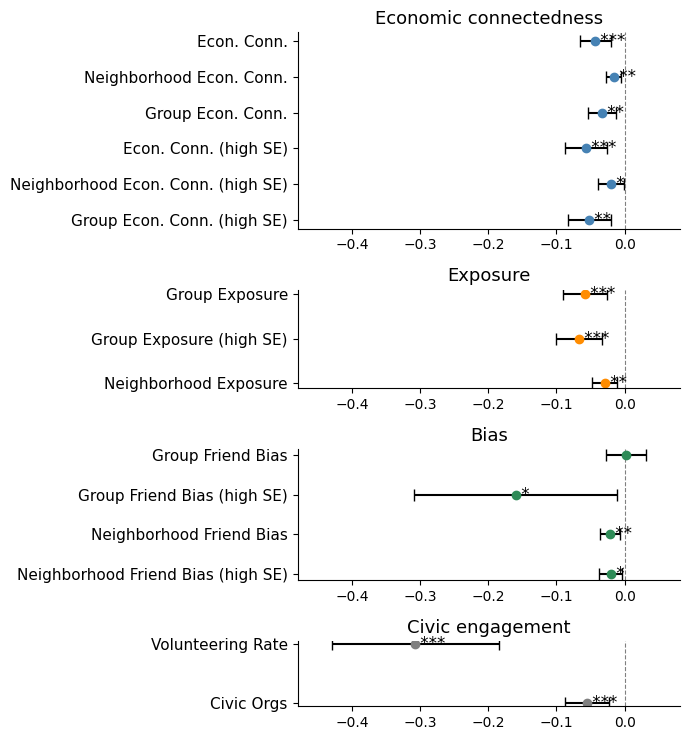

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from matplotlib import gridspec

# ==============================
# Data
# ==============================
y_var = "cum_att"

x_vars = [
    "civic_organizations_zip",
    "volunteering_rate_zip",
    "nbhd_bias_high_zip",
    "nbhd_bias_zip",
    "bias_grp_mem_high_zip",
    "bias_grp_mem_zip",
    "nbhd_exposure_zip",
    "exposure_grp_mem_high_zip",
    "exposure_grp_mem_zip",
    "ec_grp_mem_high_zip",
    "nbhd_ec_high_zip",
    "ec_high_zip",
    "ec_grp_mem_zip",
    "nbhd_ec_zip",
    "ec_zip"
]

control_vars = [
    "Median_Household_Income",
    "Black_Population_Ratio",
    "Renter_Households",
    "disasterNumber",
    "D_TH"
]

# ==============================
# Labels & colors
# ==============================
x_label_mapping = {
    "civic_organizations_zip": "Civic Orgs",
    "volunteering_rate_zip": "Volunteering Rate",
    "nbhd_bias_high_zip": "Neighborhood Friend Bias (high SE)",
    "nbhd_bias_zip": "Neighborhood Friend Bias",
    "bias_grp_mem_high_zip": "Group Friend Bias (high SE)",
    "bias_grp_mem_zip": "Group Friend Bias",
    "nbhd_exposure_zip": "Neighborhood Exposure",
    "exposure_grp_mem_high_zip": "Group Exposure (high SE)",
    "exposure_grp_mem_zip": "Group Exposure",
    "ec_grp_mem_high_zip": "Group Econ. Conn. (high SE)",
    "nbhd_ec_high_zip": "Neighborhood Econ. Conn. (high SE)",
    "ec_high_zip": "Econ. Conn. (high SE)",
    "ec_grp_mem_zip": "Group Econ. Conn.",
    "nbhd_ec_zip": "Neighborhood Econ. Conn.",
    "ec_zip": "Econ. Conn."
}

def get_category(var):
    if "ec" in var:
        return "economic connectedness"
    elif "exposure" in var:
        return "exposure"
    elif "bias" in var:
        return "bias"
    else:
        return "civic engagement"

color_mapping = {
    "economic connectedness": "steelblue",
    "exposure": "darkorange",
    "bias": "seagreen",
    "civic engagement": "grey"
}

# ==============================
# Regression
# ==============================
def run_regression(
    df,
    vars_list,
    controls,
    y_var="cum_att",
    cluster_var="disaster"
):
    results = []
    regression_results = {}
    latex_results = {}

    for x in vars_list:
        # =========================
        # Subset
        # =========================
        cols = [y_var, x] + controls
        df_sub = df[cols].copy()

        # =========================
        # numeric coercion
        # =========================
        df_sub[y_var] = pd.to_numeric(df_sub[y_var], errors="coerce")
        df_sub[x] = pd.to_numeric(df_sub[x], errors="coerce")

        df_sub = (
            df_sub
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
        )

        # =========================
        # y / X
        # =========================
        y = df_sub[y_var].astype(float)
        X = df_sub.drop(columns=[y_var])

        # =========================
        # Explicit FE handling
        # =========================
        if "disasterNumber" in X.columns:
            X["disasterNumber"] = X["disasterNumber"].astype("category")

        # =========================
        # Dummy
        # =========================
        X = pd.get_dummies(X, drop_first=True)

        X = X.astype(float)

        X = sm.add_constant(X, has_constant="add")

        # =========================
        # Cluster
        # =========================
        groups = df_sub[cluster_var]

        model = sm.OLS(y, X).fit(
            cov_type="cluster",
            cov_kwds={"groups": groups}
        )
        regression_results[x] = model

        latex_results[x] = {
            "model": model,
            "nobs": int(model.nobs),
            "r2": model.rsquared
        }

        results.append({
            "x_variable": x,
            "Coefficient": model.params[x],
            "CI_Lower": model.conf_int().loc[x, 0],
            "CI_Upper": model.conf_int().loc[x, 1],
            "p_value": model.pvalues[x]
        })

    return pd.DataFrame(results),regression_results, latex_results



# ==============================
# Plot
# ==============================
def plot_coefficients_by_category(df):
    df = df.copy()
    df["category"] = df["x_variable"].apply(get_category)

    categories = list(df["category"].unique())[::-1]
    height_ratios = [len(df[df["category"] == c]) for c in categories]

    xmin = df["CI_Lower"].min() - 0.05
    xmax = df["CI_Upper"].max() + 0.05

    fig = plt.figure(figsize=(7, sum(height_ratios) * 0.5))
    gs = gridspec.GridSpec(len(categories), 1, height_ratios=height_ratios)

    for idx, cat in enumerate(categories):
        ax = fig.add_subplot(gs[idx])
        sub = df[df["category"] == cat].reset_index(drop=True)

        for i, row in sub.iterrows():
            color = color_mapping[cat]

            # significance
            if row["p_value"] < 0.001:
                star = "***"
            elif row["p_value"] < 0.01:
                star = "**"
            elif row["p_value"] < 0.05:
                star = "*"
            elif row["p_value"] < 0.1:
                star = "†"
            else:
                star = ""

            ax.errorbar(
                row["Coefficient"], i,
                xerr=[[row["Coefficient"] - row["CI_Lower"]],
                      [row["CI_Upper"] - row["Coefficient"]]],
                fmt="o",
                color=color,
                ecolor="black",
                capsize=4
            )

            if star:
                ax.text(row["Coefficient"], i, " " + star,
                        va="center", fontsize=12)

        ax.set_yticks(range(len(sub)))
        ax.set_yticklabels(
            [x_label_mapping.get(v, v) for v in sub["x_variable"]],
            fontsize=11
        )

        ax.axvline(0, color="grey", linestyle="--", linewidth=0.8)
        ax.set_xlim(xmin, xmax)
        ax.set_title(cat.capitalize(), fontsize=13)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

# ==============================
# Run
# ==============================
df_results, regression_results, latex_results = run_regression(
    df=merged_df_clean,
    vars_list=x_vars,
    controls=control_vars,
    y_var=y_var,
    cluster_var="disasterNumber"
)


plot_coefficients_by_category(df_results)


In [ ]:
for var, model in regression_results.items():
    print("=" * 80)
    print(var)
    print(model.summary())


civic_organizations_zip
                            OLS Regression Results                            
Dep. Variable:                cum_att   R-squared:                       0.061
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     6.108
Date:                Wed, 18 Feb 2026   Prob (F-statistic):            0.00281
Time:                        15:08:52   Log-Likelihood:                 3606.7
No. Observations:                1924   AIC:                            -7171.
Df Residuals:                    1903   BIC:                            -7055.
Df Model:                          20                                         
Covariance Type:              cluster                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
co

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 20, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 20, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 20, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 20, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/usr/loc

                            OLS Regression Results                            
Dep. Variable:                cum_att   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.052
Method:                 Least Squares   F-statistic:                     7.276
Date:                Wed, 18 Feb 2026   Prob (F-statistic):            0.00122
Time:                        15:08:52   Log-Likelihood:                 3586.0
No. Observations:                1904   AIC:                            -7130.
Df Residuals:                    1883   BIC:                            -7013.
Df Model:                          20                                         
Covariance Type:              cluster                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [ ]:
use_cols = x_vars + control_vars + [y_var]

df_used = merged_df_clean[use_cols].copy()

df_used = df_used.dropna(subset=control_vars)

desc_stats = df_used.describe()

desc_stats_t = desc_stats.T.iloc[::-1]

latex_table = desc_stats_t.to_latex(float_format="%.3f", index=True)

print(latex_table)

\begin{tabular}{lrrrrrrrr}
\toprule
 & count & mean & std & min & 25% & 50% & 75% & max \\
\midrule
cum_att & 1924.000 & -0.018 & 0.038 & -0.188 & -0.037 & -0.018 & 0.002 & 0.282 \\
D_TH & 1924.000 & 0.009 & 0.017 & 0.000 & 0.000 & 0.001 & 0.009 & 0.112 \\
disasterNumber & 1924.000 & 4669.761 & 85.770 & 1724.000 & 4665.000 & 4673.000 & 4701.000 & 4751.000 \\
Renter_Households & 1924.000 & 768.077 & 939.273 & 5.000 & 372.000 & 615.000 & 975.250 & 15605.000 \\
Black_Population_Ratio & 1924.000 & 0.287 & 0.277 & 0.000 & 0.064 & 0.191 & 0.419 & 1.000 \\
Median_Household_Income & 1924.000 & 63809.659 & 29529.328 & 2499.000 & 43214.250 & 58036.000 & 78336.000 & 233542.000 \\
ec_zip & 1924.000 & 0.756 & 0.198 & 0.377 & 0.594 & 0.740 & 0.885 & 1.270 \\
nbhd_ec_zip & 1904.000 & 0.661 & 0.342 & 0.095 & 0.403 & 0.611 & 0.850 & 1.859 \\
ec_grp_mem_zip & 1924.000 & 0.824 & 0.230 & 0.351 & 0.643 & 0.820 & 0.978 & 1.411 \\
ec_high_zip & 1924.000 & 1.322 & 0.199 & 0.830 & 1.190 & 1.333 & 1.456 & 1.713

In [ ]:
pip install stargazer

In [ ]:
from statsmodels.iolib.summary2 import summary_col
import re
import math

# ==================================================
# 1. Variable groups
# ==================================================
demographics_vars = {
    "Median_Household_Income",
    "Black_Population_Ratio",
    "Renter_Households",
}

damage_index_vars = {
    "D_TH",
}

disaster_fe_prefix = "disaster"

# ==================================================
# 2. Label mapping
# ==================================================
x_label_mapping = {
    "civic_organizations_zip": "Civic Orgs",
    "volunteering_rate_zip": "Volunteering Rate",
    "nbhd_bias_high_zip": "Neighborhood Bias (high)",
    "nbhd_bias_zip": "Neighborhood Bias",
    "bias_grp_mem_high_zip": "Group Bias (high)",
    "bias_grp_mem_zip": "Group Bias",
    "nbhd_exposure_zip": "Neighborhood Exp.",
    "exposure_grp_mem_high_zip": "Group Exp. (high)",
    "exposure_grp_mem_zip": "Group Exp.",
    "ec_grp_mem_high_zip": "Group EC (high)",
    "nbhd_ec_high_zip": "Neighborhood EC (high)",
    "ec_high_zip": "EC (high)",
    "nbhd_ec_zip": "Neighborhood EC",
    "ec_grp_mem_zip": "Group EC",
    "ec_zip": "EC",
    "const": "const"
}

target_vars = list(x_label_mapping.keys())

# ==================================================
# 3. Helper functions
# ==================================================
def has_any(model, vars_set):
    return any(v in model.model.exog_names for v in vars_set)

def has_prefix(model, prefix):
    return any(v.startswith(prefix) for v in model.model.exog_names)

# ==================================================
# 4. Build LaTeX table
# ==================================================
def format_latex_table(models, start_idx):

    table = summary_col(
        models,
        stars=True,
        model_names=[f"({i})" for i in range(start_idx, start_idx + len(models))],
        info_dict={
            "Damage index": lambda x: "Yes" if has_any(x, damage_index_vars) else "No",
            "Demographics": lambda x: "Yes" if has_any(x, demographics_vars) else "No",
            "Disaster FE": lambda x: "Yes" if has_prefix(x, disaster_fe_prefix) else "No",
            "N": lambda x: f"{int(x.nobs)}",
            "R-squared": lambda x: f"{x.rsquared:.3f}",
        },
    )

    df = table.tables[0]

    # ----------------------------------------------
    # ① Vars
    # ----------------------------------------------
    keep_pos = set()
    n = len(df)
    summary_rows = {"R-squared", "R-squared Adj.", "N", "Damage index", "Demographics", "Disaster FE"}

    for i in range(n):
        idx = df.index[i]
        base = re.sub(r"\(.*\)", "", idx).strip()

        if base in target_vars:
            keep_pos.add(i)
            if i + 1 < n:
                keep_pos.add(i + 1)
        elif base in summary_rows:
            keep_pos.add(i)

    df = df.iloc[sorted(keep_pos)]

    # ----------------------------------------------
    # ② index label
    # ----------------------------------------------
    new_index = []
    last_label = ""

    for idx in df.index:
        base = re.sub(r"\(.*\)", "", idx).strip()

        if base in x_label_mapping:
            label = x_label_mapping[base]
            last_label = label
        else:
            if "(" in idx:
                label = f"{last_label} {idx}"
            else:
                label = base

        new_index.append(label)

    df.index = new_index

    # ----------------------------------------------
    # ③ LaTeX
    # ----------------------------------------------
    table.tables[0] = df
    latex = table.as_latex()

    latex = latex.replace(
        r"\begin{table}",
        r"\begin{table}\footnotesize"
    )

    latex = re.sub(
        r"(-?\d+\.\d+)",
        lambda m: f"{float(m.group()):.3f}",
        latex,
    )

    latex = re.sub(
        r"(\*{1,3})",
        r"$^{\\tiny \1}$",
        latex
    )

    return latex

# ==================================================
# 5. Split models
# ==================================================
models = [v["model"] for v in reversed(latex_results.values())]

mid = math.ceil(len(models) / 2)
models_left = models[:mid]
models_right = models[mid:]

latex_left = format_latex_table(models_left, 1)
latex_right = format_latex_table(models_right, mid + 1)

print(latex_left)
print(latex_right)


\begin{table}\footnotesize
\caption{}
\label{}
\begin{center}
\begin{tabular}{lllllllll}
\hline
                       & (1)        & (2)        & (3)        & (4)        & (5)       & (6)        & (7)        & (8)         \\
\hline
const                  & -0.014    & -0.030    & -0.016    & 0.018     & -0.023   & 0.024     & 0.009     & 0.036      \\
                       & (0.025)   & (0.022)   & (0.025)   & (0.031)   & (0.025)  & (0.033)   & (0.029)   & (0.033)    \\
EC                     & -0.043$^{\tiny ***}$ &            &            &            &           &            &            &             \\
                       & (0.012)   &            &            &            &           &            &            &             \\
Neighborhood EC        &            & -0.016$^{\tiny ***}$ &            &            &           &            &            &             \\
                       &            & (0.006)   &            &            &           &            &            & 